# Objectiu: Influència del mètode de pagament en l'abandonament

Ara és moment de veure si hi ha alguna relació amb el mètode de pagament i l'abandonament de la companyia de telecomunicacions.

Primer de tot farem un estudi general de quines taxes d'abandonament tenen els diferents mètodes de pagaments per veure si hi ha alguna relació clara.  

Carreguem les biblioteques que utilitzarem al llarg del notebook.

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Carreguem el fitxer `abandonament_editat.csv`. 

In [9]:
df_aband=pd.read_csv('abandonament_editat.csv')

Veiem quines són les taxes d'abandonament segons el mètode de pagament.

C:\Users\oscar\AppData\Local\Temp\ipykernel_68268\2019721069.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Aband_si['Electronic check']=t1[1]
C:\Users\oscar\AppData\Local\Temp\ipykernel_68268\2019721069.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Aband_si['Mailed check']=t2[1]
C:\Users\oscar\AppData\Local\Temp\ipykernel_68268\2019721069.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Aband_si['Bank transfer (autom

Text(0.5, 0, 'Mètode de pagament')

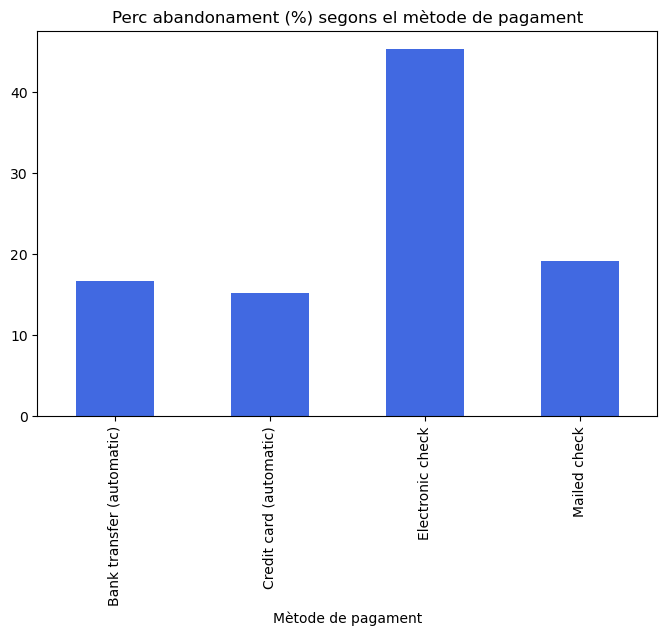

In [24]:
g=df_aband.groupby('PaymentMethod')
aband=g['Churn'].value_counts(normalize=True)*100
t1=aband.loc['Electronic check']
t2=aband.loc['Mailed check']
t3=aband.loc['Bank transfer (automatic)']
t4=aband.loc['Credit card (automatic)']
Aband_si=g['MonthlyCharges'].mean()
Aband_si['Electronic check']=t1[1]
Aband_si['Mailed check']=t2[1]
Aband_si['Bank transfer (automatic)']=t3[1]
Aband_si['Credit card (automatic)']=t4[1]
Aband_si=Aband_si.rename('Perc abandonament(%)')
Aband_si.plot(kind='bar', figsize=(8, 5), color='royalblue')
plt.title('Perc abandonament (%) segons el mètode de pagament')
plt.xlabel('Mètode de pagament')

>Com es pot observar, clarament aquells que fan el pagament amb xec electrònic tendeixen a abandonar més la companyia de telecomunicacions. Quasi un 50% de clients que efectuant aquest mètode de pagament acaben abandonant la companyia. 
En canvi, la resta de mètodes de pagament tenen una taxa d'abandonament baixa i bastant igualada, entorn al 17%. 

Si bé recordeu, a l'anàlisi del fitxer "abandonament.csv" vam crear una nova columna on classificàvem als clients segons si el seu mètode de pagament era automàtic o no. Entenem per automàtic que tu no fas la transacció directament sinó que cada mes et van cobrant automàticament. A continuació veurem quines són les taxes d'abandonament segons aquest criteri per aprofundir més en la influència del mètode de pagament i la permanència a la companyia. 

C:\Users\oscar\AppData\Local\Temp\ipykernel_68268\997265446.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Aband_si['Yes']=t1[1]
C:\Users\oscar\AppData\Local\Temp\ipykernel_68268\997265446.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Aband_si['No']=t2[1]


Text(0.5, 0, 'Mètode de pagament automàtic')

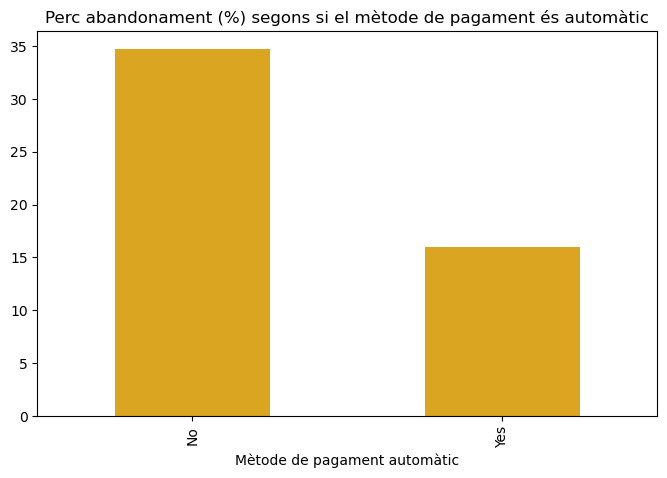

In [32]:
g=df_aband.groupby('AutomaticPayment')
aband=g['Churn'].value_counts(normalize=True)*100
t1=aband.loc['Yes']
t2=aband.loc['No']
Aband_si=g['MonthlyCharges'].mean()
Aband_si['Yes']=t1[1]
Aband_si['No']=t2[1]
Aband_si.plot(kind='bar', figsize=(8, 5), color='goldenrod')
plt.title('Perc abandonament (%) segons si el mètode de pagament és automàtic')
plt.xlabel('Mètode de pagament automàtic')

>Veiem com aquells clients que NO tenen un mètode de pagament automàtic tendeixen a abandonar més l'empresa de telecomunicacions que aquells que sí que ho tenen. En l'apartat anterior ja podíem predir aquest resultat, ja que el mètode que té major taxa d'abandonament i amb molta diferència dels altres era el de xec electrònic i aquest no és automàtic. 